# USA radii exposure

In [6]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

The jupyter_black extension is already loaded. To reload it, use:
  %reload_ext jupyter_black
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
import ocha_stratus as stratus
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from src.utils.exposure import calculate_single_adm_exposure

In [8]:
blob_name = "ds-storm-impact-harmonisation/processed/ibtracs_usa_buffers.parquet"

In [9]:
gdf_buffers = stratus.load_geoparquet_from_blob(blob_name)

In [10]:
url = "https://data.fieldmaps.io/adm0/osm/intl/adm0_polygons.parquet"

adm0 = gpd.read_parquet(f"simplecache::{url}")

In [11]:
url = "https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_countries.zip"
adm0 = gpd.read_file(url)

<Axes: >

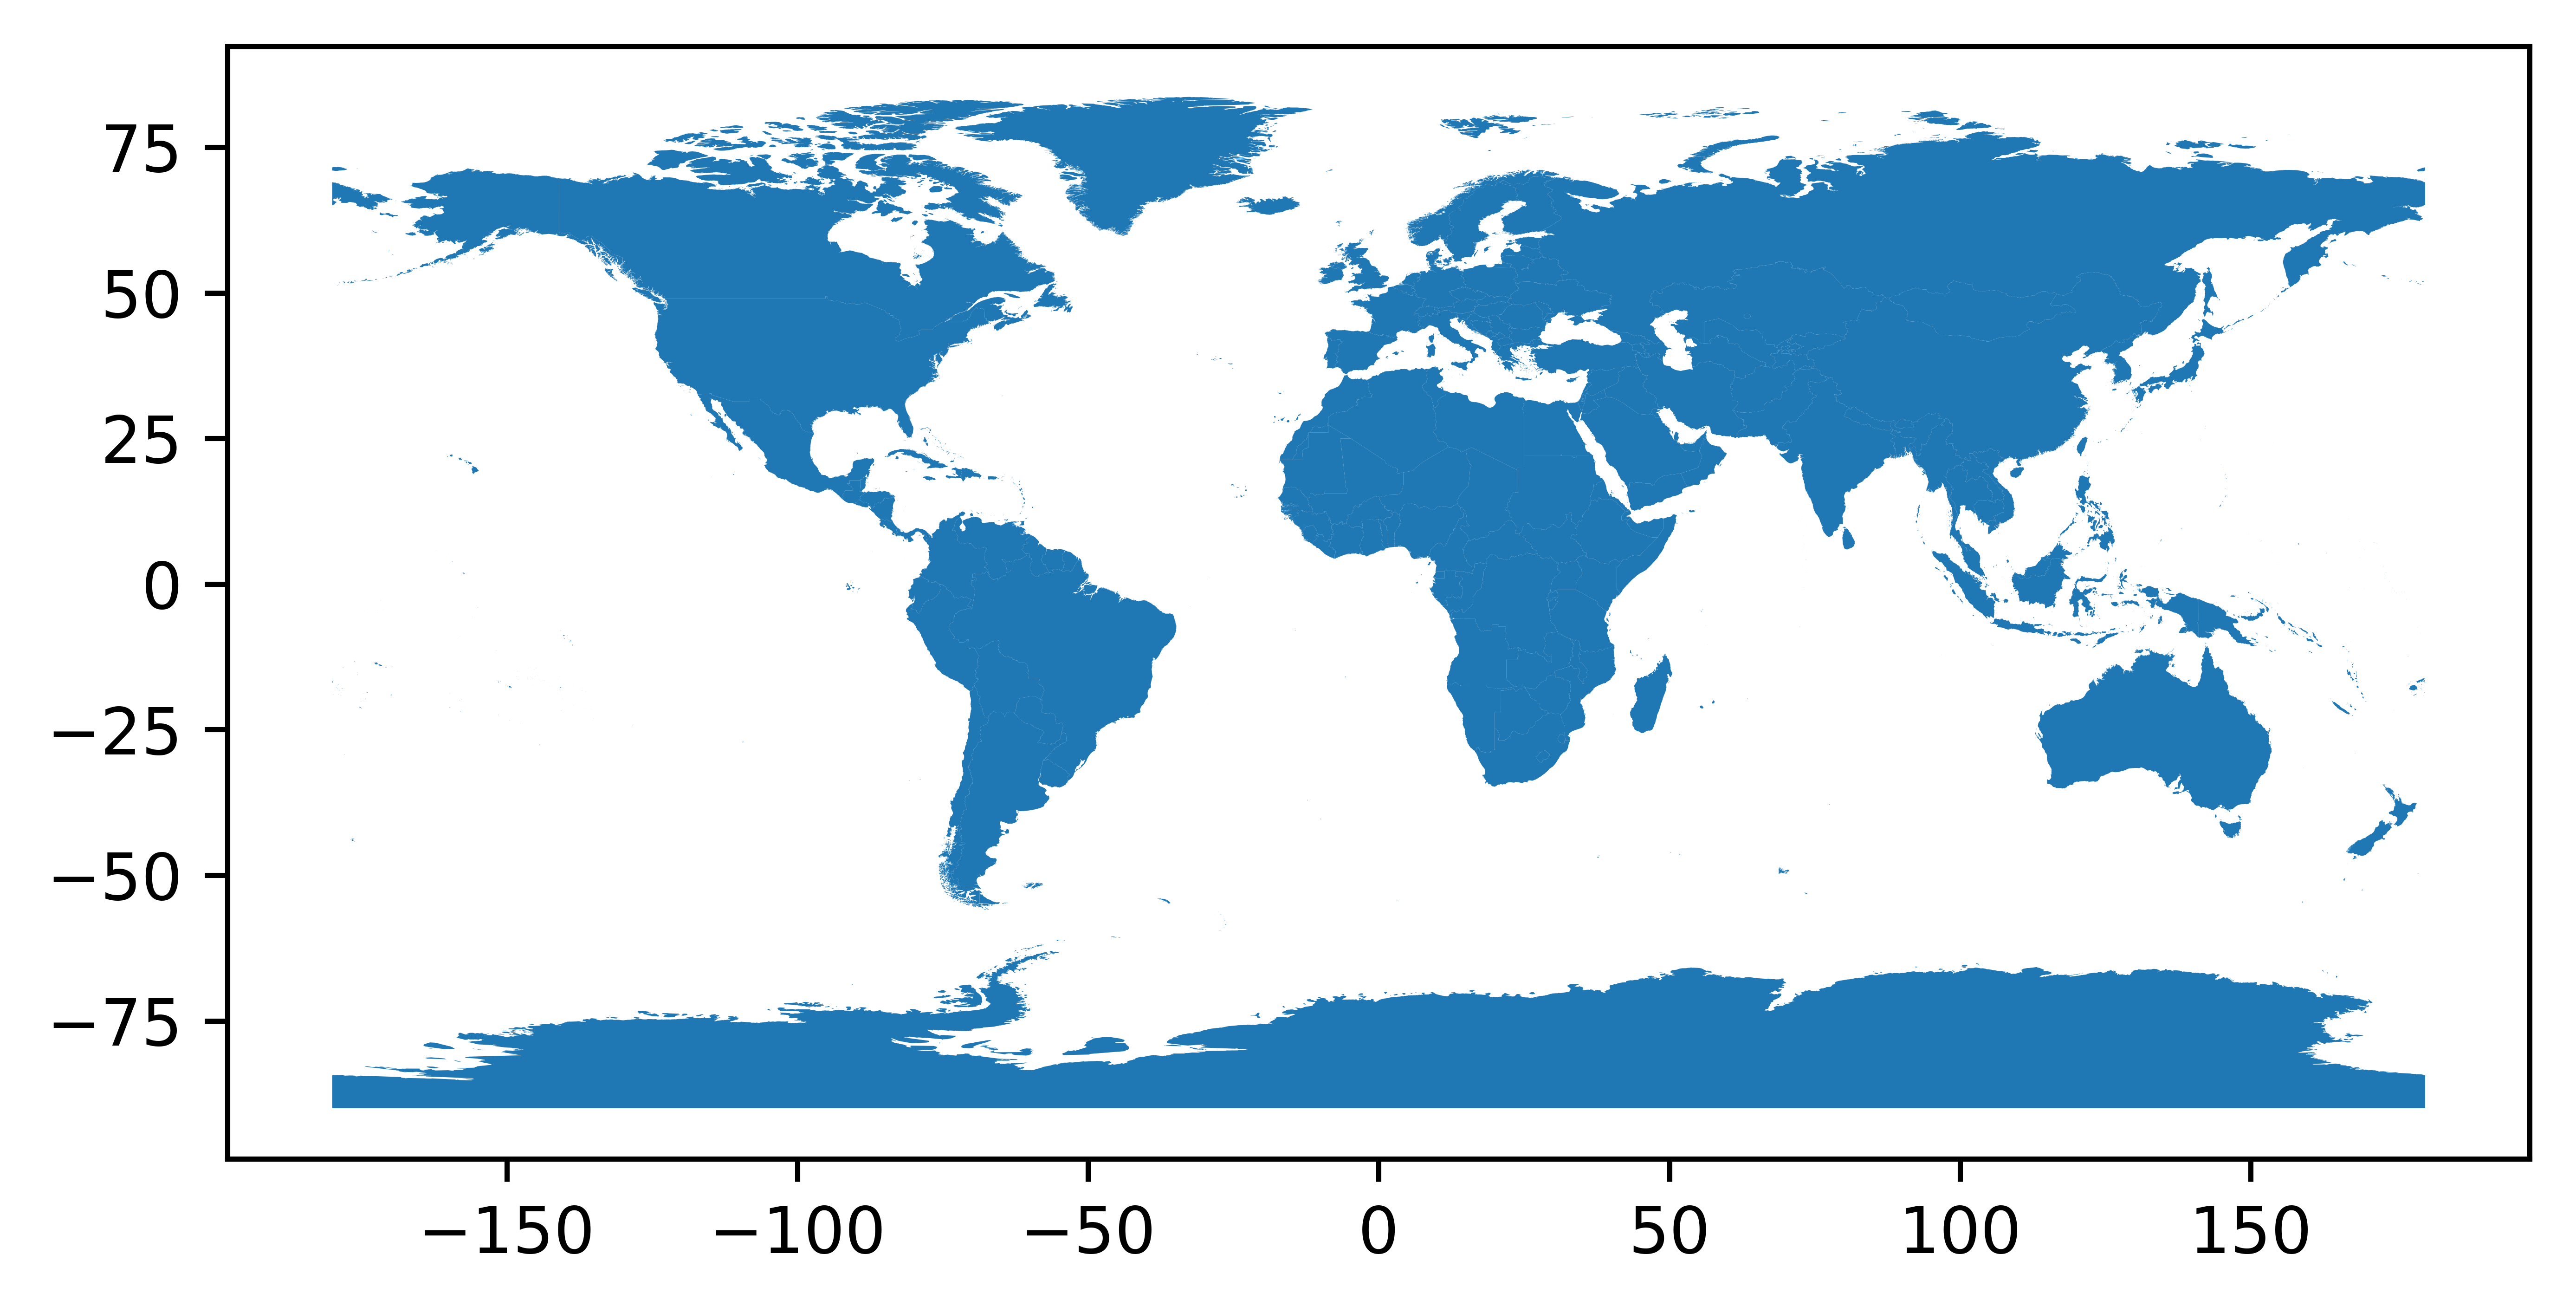

In [12]:
fig, ax = plt.subplots(dpi=1000)
adm0.plot(ax=ax)

<Axes: >

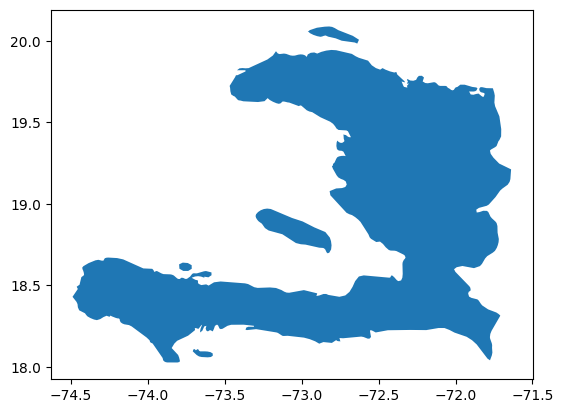

In [13]:
iso3 = "hti"
adm0[adm0["ISO_A3"] == iso3.upper()].plot()

In [14]:
blob_name = "worldpop/pop_count/global_pop_2026_CN_1km_R2025A_UA_v1.tif"
da_wp_global = stratus.open_blob_cog(blob_name, container_name="raster")

/Users/tdowning/OCHA/repos/ds-storm-impact-harmonisation/.venv/lib/python3.11/site-packages/rioxarray/_io.py:939: FutureWarning: Supplying chunks as dimension-order tuples is deprecated. It will raise an error in the future. Instead use a dict with dimension names as keys.
  return result.chunk(chunks, name_prefix=name_prefix, token=token)


In [15]:
da_wp_global = da_wp_global.squeeze(drop=True)

In [16]:
da_wp_global

<xarray.DataArray (y: 17280, x: 43200)> Size: 3GB
dask.array<getitem, shape=(17280, 43200), dtype=float32, chunksize=(5632, 5632), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 138kB 84.0 83.99 83.98 ... -59.98 -59.99 -60.0
  * x            (x) float64 346kB -180.0 -180.0 -180.0 ... 180.0 180.0 180.0
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    _FillValue:     -99999.0
    scale_factor:   1.0
    add_offset:     0.0

In [17]:
adm0_plot = adm0[adm0["ISO_A3"] == iso3.upper()]
minx, miny, maxx, maxy = adm0_plot.total_bounds

In [18]:
da_clip = da_wp_global.sel(
    x=slice(minx, maxx), y=slice(maxy, miny)  # y reversed if descending
)

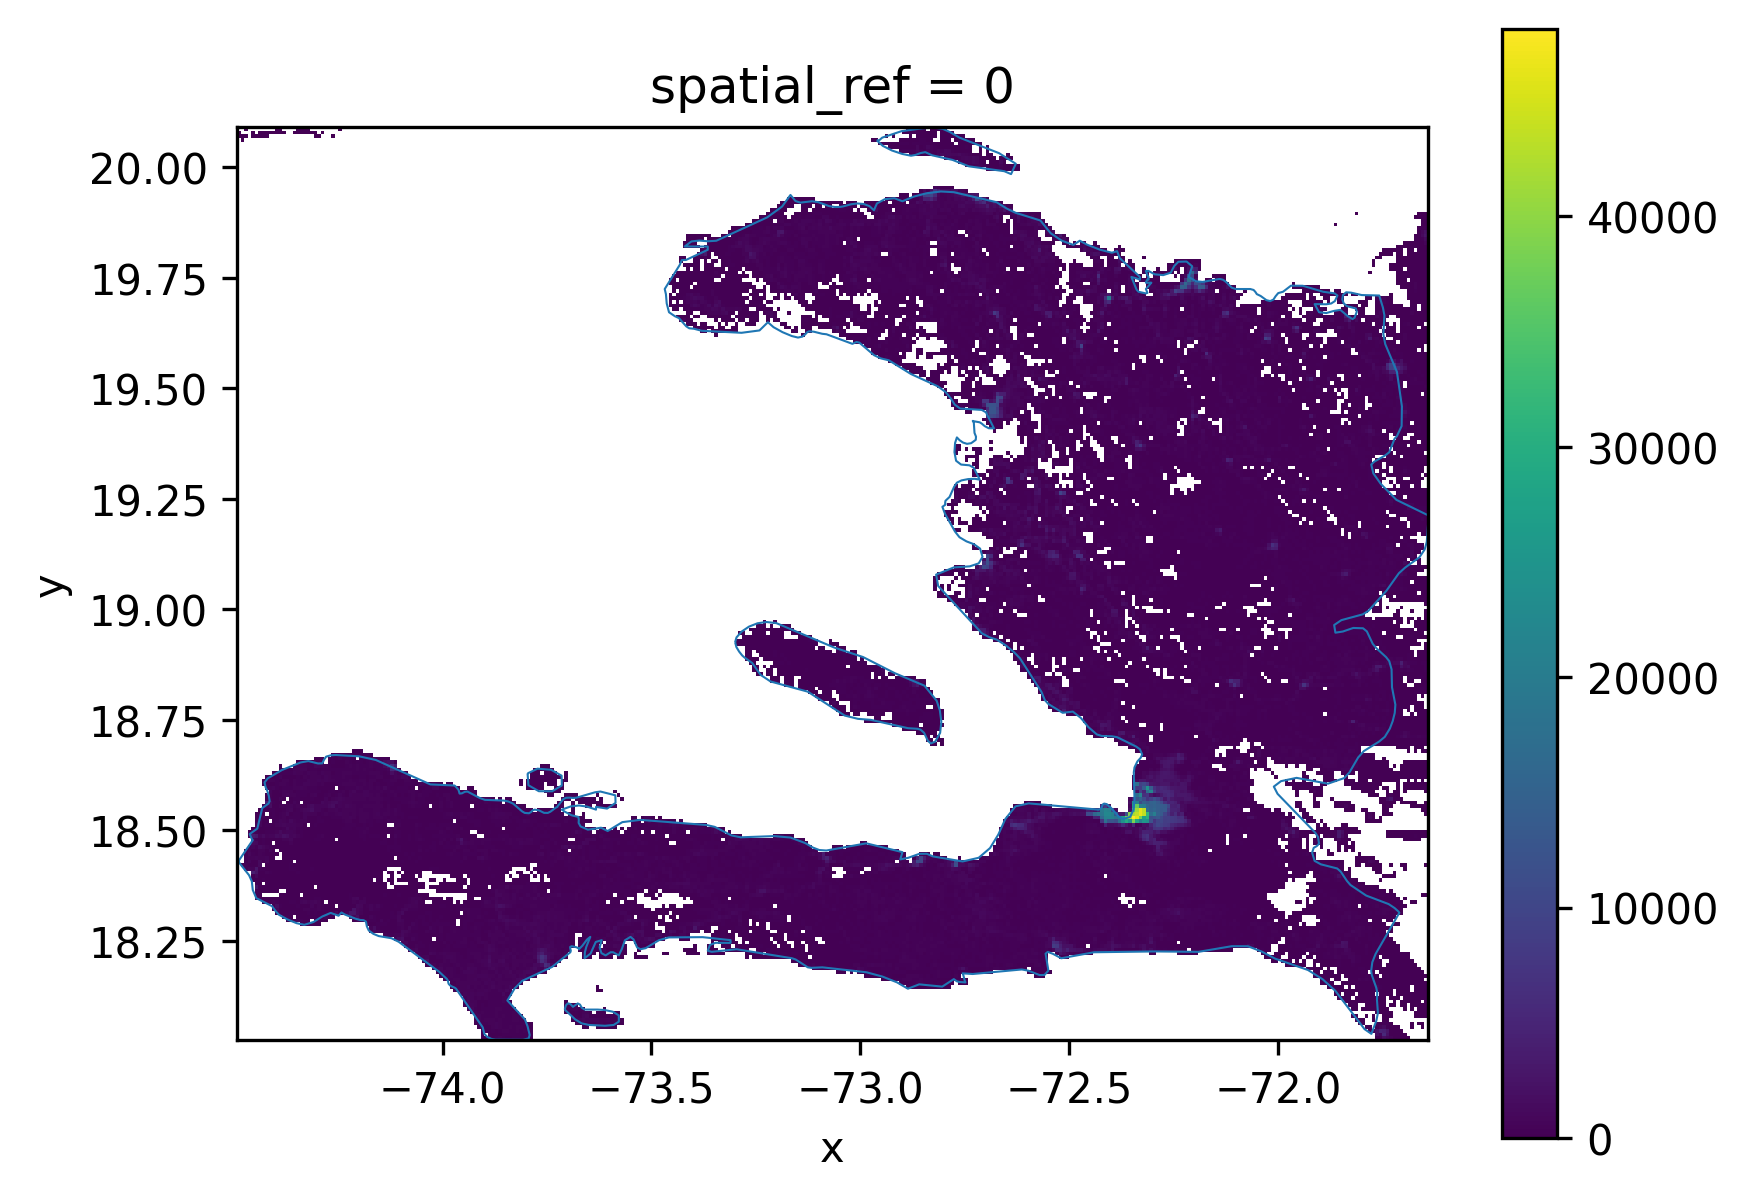

In [19]:
fig, ax = plt.subplots(dpi=300)
adm0_plot.boundary.plot(ax=ax, linewidth=0.5)
da_clip.where(da_clip > 0).plot(ax=ax)

In [20]:
GEO_CRS_MERIDIAN = "+proj=longlat +datum=WGS84 +lon_wrap=0"
GEO_CRS_ANTIMERIDIAN = "+proj=longlat +datum=WGS84 +lon_wrap=180"

In [21]:
adm0_plot = adm0[adm0["ADM0_A3"] == "FJI"]
# adm0_plot = adm0_plot.to_crs(GEO_CRS_ANTIMERIDIAN)

In [22]:
adm0_plot.total_bounds

array([-180.        ,  -21.71111419,  180.        ,  -12.47527435])

In [23]:
adm0.columns

Index(['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3',
       'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN',
       ...
       'FCLASS_TR', 'FCLASS_ID', 'FCLASS_PL', 'FCLASS_GR', 'FCLASS_IT',
       'FCLASS_NL', 'FCLASS_SE', 'FCLASS_BD', 'FCLASS_UA', 'geometry'],
      dtype='str', length=169)

In [24]:
adm0.groupby("ADM0_A3").size().max()

np.int64(1)

In [25]:
import warnings
from rasterio.errors import ShapeSkipWarning

warnings.filterwarnings("ignore", category=ShapeSkipWarning)

In [26]:
adm0_group.to_crs(GEO_CRS_ANTIMERIDIAN).plot()

NameError: name 'adm0_group' is not defined

In [28]:
existing_blobs = stratus.list_container_blobs(
    name_starts_with="ds-storm-impact-harmonisation/processed/adm0_ibtracs_exp/"
)

In [29]:
existing_blobs

['ds-storm-impact-harmonisation/processed/adm0_ibtracs_exp/abw_exp.parquet',
 'ds-storm-impact-harmonisation/processed/adm0_ibtracs_exp/afg_exp.parquet',
 'ds-storm-impact-harmonisation/processed/adm0_ibtracs_exp/ago_exp.parquet',
 'ds-storm-impact-harmonisation/processed/adm0_ibtracs_exp/aia_exp.parquet',
 'ds-storm-impact-harmonisation/processed/adm0_ibtracs_exp/are_exp.parquet',
 'ds-storm-impact-harmonisation/processed/adm0_ibtracs_exp/arg_exp.parquet',
 'ds-storm-impact-harmonisation/processed/adm0_ibtracs_exp/asm_exp.parquet',
 'ds-storm-impact-harmonisation/processed/adm0_ibtracs_exp/atc_exp.parquet',
 'ds-storm-impact-harmonisation/processed/adm0_ibtracs_exp/atf_exp.parquet',
 'ds-storm-impact-harmonisation/processed/adm0_ibtracs_exp/atg_exp.parquet',
 'ds-storm-impact-harmonisation/processed/adm0_ibtracs_exp/aus_exp.parquet',
 'ds-storm-impact-harmonisation/processed/adm0_ibtracs_exp/ben_exp.parquet',
 'ds-storm-impact-harmonisation/processed/adm0_ibtracs_exp/bfa_exp.parquet',

In [30]:
adm_index_col = "ADM0_A3"

da_wp_wrapped = da_wp_global.assign_coords(
    {"x": ((da_wp_global.x + 360) % 360)}
).sortby("x")

gdf_buffers_antimeridian = gdf_buffers.to_crs(GEO_CRS_ANTIMERIDIAN)

for adm_index, adm0_group in tqdm(adm0.groupby(adm_index_col)):
    blob_name = f"ds-storm-impact-harmonisation/processed/adm0_ibtracs_exp/{adm_index.lower()}_exp.parquet"

    adm_row = adm0_group.iloc[0]
    adm_name = adm_row["NAME"]
    if blob_name in existing_blobs:
        print(f"already done for {adm_name}")
        continue

    minx, miny, maxx, maxy = adm0_group.total_bounds
    wrap_antimeridian = maxx > 160 or minx < -160

    if wrap_antimeridian:
        da_wp_work = da_wp_wrapped
        adm0_work = adm0_group.to_crs(GEO_CRS_ANTIMERIDIAN)
        gdf_buffers_work = gdf_buffers_antimeridian
    else:
        da_wp_work = da_wp_global
        adm0_work = adm0_group
        gdf_buffers_work = gdf_buffers

    buffers_in_country = gdf_buffers_work[
        gdf_buffers_work.intersects(adm0_work.iloc[0].geometry)
    ]

    if buffers_in_country.empty:
        print(f"no buffer overlap with {adm_name}")
        continue

    da_wp_adm = da_wp_work.rio.clip(adm0_work.geometry, all_touched=True)

    _df_exp = calculate_single_adm_exposure(buffers_in_country, da_wp_adm)
    _df_exp[adm_index_col] = adm_index

    stratus.upload_parquet_to_blob(_df_exp, blob_name)

    del da_wp_adm

python(42408) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
  6%|████████████▋                                                                                                                                                                                               | 16/258 [00:00<00:01, 159.31it/s]

already done for Aruba
already done for Afghanistan
already done for Angola
already done for Anguilla
no buffer overlap with Albania
no buffer overlap with Åland
no buffer overlap with Andorra
already done for United Arab Emirates
already done for Argentina
no buffer overlap with Armenia
already done for American Samoa
no buffer overlap with Antarctica
already done for Ashmore and Cartier Is.
already done for Fr. S. Antarctic Lands
already done for Antigua and Barb.
already done for Australia
no buffer overlap with Austria
no buffer overlap with Azerbaijan
no buffer overlap with Burundi
no buffer overlap with Belgium
already done for Benin
already done for Burkina Faso
already done for Bangladesh
no buffer overlap with Bulgaria
already done for Bahrain
already done for Bahamas
no buffer overlap with Bosnia and Herz.
already done for Bajo Nuevo Bank
already done for St-Barthélemy
no buffer overlap with Belarus
already done for Belize
already done for Bermuda
already done for Bolivia
alr

 19%|██████████████████████████████████████▏                                                                                                                                                                      | 48/258 [00:24<02:34,  1.36it/s]

no buffer overlap with Cyprus U.N. Buffer Zone


 19%|███████████████████████████████████████▋                                                                                                                                                                     | 50/258 [00:32<03:28,  1.00s/it]

...

 95%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉           | 244/258 [35:50<13:47, 59.08s/it]

no buffer overlap with Vatican


 98%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████    | 253/258 [37:20<01:06, 13.34s/it]

no buffer overlap with Akrotiri


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 258/258 [38:04<00:00,  8.85s/it]


In [31]:
existing_blobs = stratus.list_container_blobs(
    name_starts_with="ds-storm-impact-harmonisation/processed/adm0_ibtracs_exp/"
)

In [32]:
dfs = []
for blob_name in tqdm(existing_blobs):
    _df_in = stratus.load_parquet_from_blob(blob_name)
    _df_in = _df_in[_df_in["pop_exposed"] > 0]
    if not _df_in.empty:
        dfs.append(_df_in)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 182/182 [01:03<00:00,  2.85it/s]


In [34]:
df_exp_all = pd.concat(dfs, ignore_index=True)

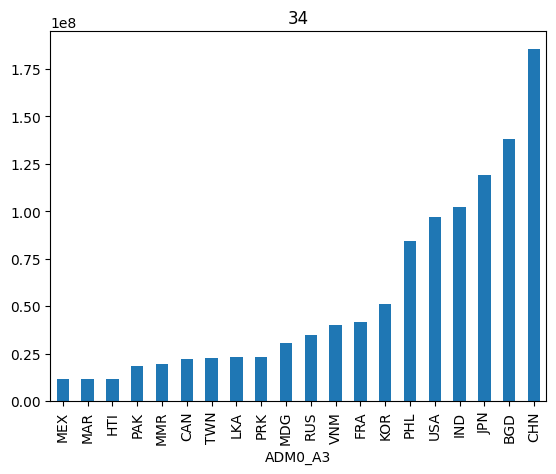

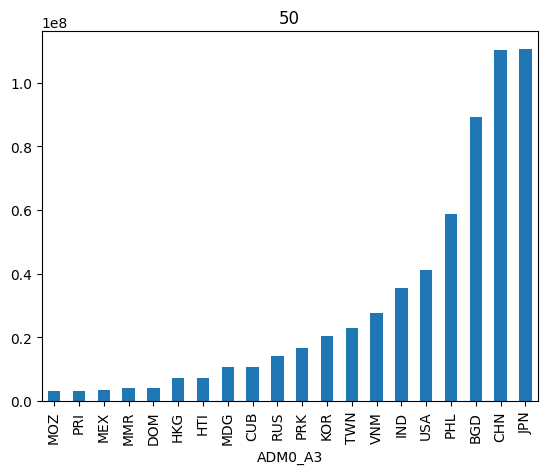

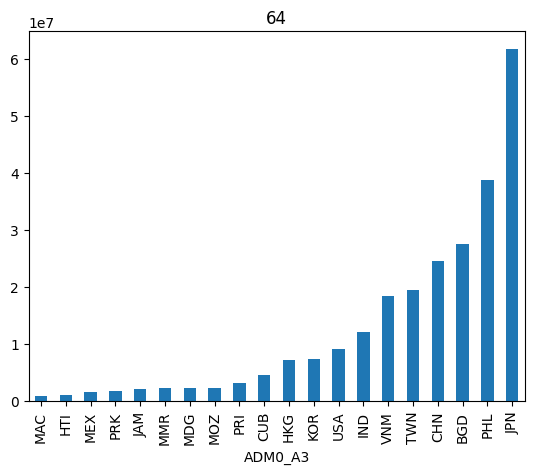

In [56]:
for speed, group in df_exp_all.groupby("speed"):
    fig, ax = plt.subplots()
    group.groupby("ADM0_A3")["pop_exposed"].max().sort_values(ascending=True).iloc[
        -20:
    ].plot.bar(ax=ax)
    ax.set_title(speed)

In [63]:
df_exp_sid_sum = df_exp_all.groupby(["sid", "speed"])["pop_exposed"].sum().reset_index()

In [65]:
df_exp_sid_sum.sort_values("pop_exposed", ascending=False).iloc[:20]

,sid,speed,pop_exposed
1580,2018250N12170,34,231804598
1660,2019214N15134,34,197836413
526,2007314N10093,34,187839687
110,2003240N20139,34,184382882
1371,2016288N06146,34,170230927
614,2008262N16142,34,162631361
1052,2013259N17132,34,161218229
2283,2025200N19123,34,160483621
574,2008169N08135,34,157722654
1430,2017232N19130,34,156592345


In [69]:
df_exp_sid_sum[df_exp_sid_sum["speed"] == 50].sort_values(
    "pop_exposed", ascending=False
).iloc[:20]

,sid,speed,pop_exposed
1581,2018250N12170,50,129887291
1587,2018263N12146,50,110520336
1053,2013259N17132,50,106185076
527,2007314N10093,50,96793197
1661,2019214N15134,50,96692070
1320,2016211N11128,50,95173068
1702,2019278N16165,50,91297410
1129,2014190N08154,50,73076285
871,2011253N20145,50,62590856
1431,2017232N19130,50,60157630


In [67]:
df_exp_sid_sum[df_exp_sid_sum["speed"] == 64].sort_values(
    "pop_exposed", ascending=False
).iloc[:20]

,sid,speed,pop_exposed
1703,2019278N16165,64,61678400
490,2007240N17153,64,45914620
576,2008169N08135,64,38694168
1582,2018250N12170,64,37602399
409,2006268N12129,64,36924215
1588,2018263N12146,64,36171032
1728,2019329N09160,64,35201448
1851,2020313N08135,64,33021428
1130,2014190N08154,64,29274524
528,2007314N10093,64,28829821


In [68]:
df_exp_all["sid"].nunique()

1271

In [71]:
df_exp_all.groupby(["sid", "ADM0_A3"]).size()

sid            ADM0_A3
2001125N05129  JPN        1
2001157N28265  USA        1
2001202N11266  MEX        1
2001202N23152  JPN        1
2001204N19127  CHN        1
                         ..
2026035N09133  PHL        1
2026037S18122  AUS        1
2026039S18057  MDG        1
               MOZ        1
2026058S18168  VUT        1
Length: 2744, dtype: int64

In [72]:
df_exp_all

,speed,sid,pop_exposed,ADM0_A3
0,34,2004247N10332,102169,ABW
1,34,2007244N12303,102169,ABW
2,34,2016273N13300,74581,ABW
3,34,2022179N08310,102169,ABW
4,34,2004238N11325,13655,AIA
...,...,...,...,...
4462,34,2012056S13057,166601,ZAF
4463,34,2007043S11071,390601,ZWE
4464,34,2019063S18038,1666293,ZWE
4465,50,2019063S18038,101,ZWE


In [57]:
blob_name = "ds-storm-impact-harmonisation/processed/adm0_ibtracs_exp_all.parquet"

In [58]:
stratus.upload_parquet_to_blob(df_exp_all, blob_name)

In [61]:
df_exp_all["sid"].min()

'2001125N05129'